# Part 4 — Pembangunan Dataset: DAIC-WOZ
**Pipeline**: Klasifikasi Kesehatan Mental Berbasis Audio (DAIC-WOZ)
**Peran**: ML & Data Engineer — Athila Ramdani Saputra

Notebook ini bertugas untuk:
1. Merge feature matrix (Part 3) + metadata label (Part 1)
2. Analisis kualitas fitur: cek nilai NaN, konstan, dan outlier
3. Hapus fitur redundan (korelasi > 0.95)
4. Seleksi fitur menggunakan ANOVA F-test & Mutual Information
   (Keduanya mendukung multiclass secara native)
5. Simpan `daic_features_final.csv` yang siap untuk training

**Kelas Target**: 0=Stress | 1=Kecemasan | 2=Depresi (via PHQ-8 proxy)
**Catatan**: StandardScaler dilakukan di Part 5 (fit hanya pada train set)


In [1]:
import os
import sys
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport.")


Library berhasil diimport.


## Konfigurasi Path


In [2]:
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.path.abspath(os.getcwd())

BASE_DIR      = os.path.dirname(os.path.dirname(current_dir))
PROCESSED_DIR = os.path.join(BASE_DIR, 'dataset', 'processed')
OUTPUT_DIR    = os.path.join(BASE_DIR, 'docs', 'assets', 'images', 'daic')

FEAT_RAW_PATH = os.path.join(PROCESSED_DIR, 'daic_features_raw.csv')
META_PATH     = os.path.join(PROCESSED_DIR, 'daic_metadata.csv')
OUTPUT_FINAL  = os.path.join(PROCESSED_DIR, 'daic_features_final.csv')

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Input features : {FEAT_RAW_PATH}")
print(f"Output final   : {OUTPUT_FINAL}")


Input features : d:\repositories\menthealth-ml\dataset\processed\daic_features_raw.csv
Output final   : d:\repositories\menthealth-ml\dataset\processed\daic_features_final.csv


## 4.1 — Load & Merge Data


In [3]:
df_feat = pd.read_csv(FEAT_RAW_PATH)
df_meta = pd.read_csv(META_PATH)

print(f"Feature matrix shape  : {df_feat.shape}")
print(f"Metadata shape        : {df_meta.shape}")
print(f"\nKolom metadata tersedia: {list(df_meta.columns)}")

# Merge berdasarkan participant_id
df = df_feat.copy()

# Pastikan kolom metadata yang dibutuhkan ada
meta_needed = ['participant_id', 'phq8_score', 'label_3kelas', 'severity']
for col in meta_needed:
    if col not in df.columns and col in df_meta.columns:
        df = df.merge(df_meta[['participant_id', col]], on='participant_id', how='left')

print(f"\nShape setelah merge: {df.shape}")
print(f"\nDistribusi 3 Kelas (Stress=0 | Kecemasan=1 | Depresi=2):")
vc = df['label_3kelas'].value_counts().sort_index()
for k, cnt in vc.items():
    names = {0:'Stress', 1:'Kecemasan', 2:'Depresi'}
    print(f"  Kelas {k} ({names.get(k,'?'):10s}): {cnt} ({cnt/len(df)*100:.1f}%)")


Feature matrix shape  : (188, 118)
Metadata shape        : (189, 9)

Kolom metadata tersedia: ['participant_id', 'folder_path', 'has_audio', 'has_transcript', 'has_covarep', 'complete', 'phq8_score', 'label_3kelas', 'severity']

Shape setelah merge: (188, 118)

Distribusi 3 Kelas (Stress=0 | Kecemasan=1 | Depresi=2):
  Kelas 0 (Stress    ): 82 (43.6%)
  Kelas 1 (Kecemasan ): 90 (47.9%)
  Kelas 2 (Depresi   ): 16 (8.5%)


## 4.2 — Identifikasi Kolom Fitur vs Metadata


In [4]:
META_COLS = ['participant_id', 'phq8_score', 'label_3kelas', 'severity']
FEAT_COLS = [c for c in df.columns if c not in META_COLS]

print(f"Jumlah fitur awal   : {len(FEAT_COLS)}")
print(f"Jumlah metadata col : {len(META_COLS)}")
print(f"\nSample nama fitur (10 pertama):")
for f in FEAT_COLS[:10]:
    print(f"  {f}")


Jumlah fitur awal   : 114
Jumlah metadata col : 4

Sample nama fitur (10 pertama):
  mfcc_1_mean
  mfcc_1_std
  mfcc_1_min
  mfcc_1_max
  mfcc_1_p25
  mfcc_1_p75
  mfcc_2_mean
  mfcc_2_std
  mfcc_2_min
  mfcc_2_max


## 4.3 — Analisis Kualitas Fitur
Memeriksa: (1) nilai NaN, (2) fitur konstan (std = 0), (3) outlier ekstrem.


In [5]:
print("=== Analisis Kualitas Fitur ===\n")

# 1. Cek NaN
nan_counts = df[FEAT_COLS].isnull().sum()
feats_with_nan = nan_counts[nan_counts > 0]
print(f"Fitur dengan NaN  : {len(feats_with_nan)}")
if len(feats_with_nan) > 0:
    print(feats_with_nan)

# Isi NaN dengan median per fitur
df[FEAT_COLS] = df[FEAT_COLS].fillna(df[FEAT_COLS].median())
print("→ NaN diisi dengan nilai median per fitur.")

# 2. Cek fitur konstan (std ≈ 0)
std_vals = df[FEAT_COLS].std()
const_feats = std_vals[std_vals < 1e-8].index.tolist()
print(f"\nFitur konstan (std < 1e-8): {len(const_feats)}")
if const_feats:
    print(f"  → Dihapus: {const_feats}")
    FEAT_COLS = [f for f in FEAT_COLS if f not in const_feats]

# 3. Cek outlier (nilai absolut > 1000x IQR)
Q1 = df[FEAT_COLS].quantile(0.25)
Q3 = df[FEAT_COLS].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = ((df[FEAT_COLS] < (Q1 - 10 * IQR)) | (df[FEAT_COLS] > (Q3 + 10 * IQR))).any(axis=1)
n_outlier_rows = outlier_mask.sum()
print(f"\nBaris dengan outlier ekstrem: {n_outlier_rows}")
# Clip outlier ke batas 10×IQR (tidak dibuang, hanya dibatasi)
for col in FEAT_COLS:
    lower = Q1[col] - 10 * IQR[col]
    upper = Q3[col] + 10 * IQR[col]
    df[col] = df[col].clip(lower=lower, upper=upper)
print("→ Outlier ekstrem di-clip ke batas 10×IQR.")

print(f"\nJumlah fitur setelah pembersihan: {len(FEAT_COLS)}")


=== Analisis Kualitas Fitur ===

Fitur dengan NaN  : 0
→ NaN diisi dengan nilai median per fitur.

Fitur konstan (std < 1e-8): 0

Baris dengan outlier ekstrem: 43
→ Outlier ekstrem di-clip ke batas 10×IQR.

Jumlah fitur setelah pembersihan: 114


## 4.4 — Hapus Fitur Redundan (Korelasi Tinggi)
Fitur yang berkorelasi > 0.95 satu sama lain dihapus untuk mengurangi
multikolinieritas yang dapat mengganggu model SVM dan Logistic Regression.


Menghitung correlation matrix (114 × 114)...
Fitur yang dihapus (korelasi > 0.95): 28
  Contoh 5 pertama: ['mfcc_1_p25', 'mfcc_1_p75', 'mfcc_2_p25', 'mfcc_3_p25', 'mfcc_3_p75']
Fitur tersisa setelah filter korelasi: 86


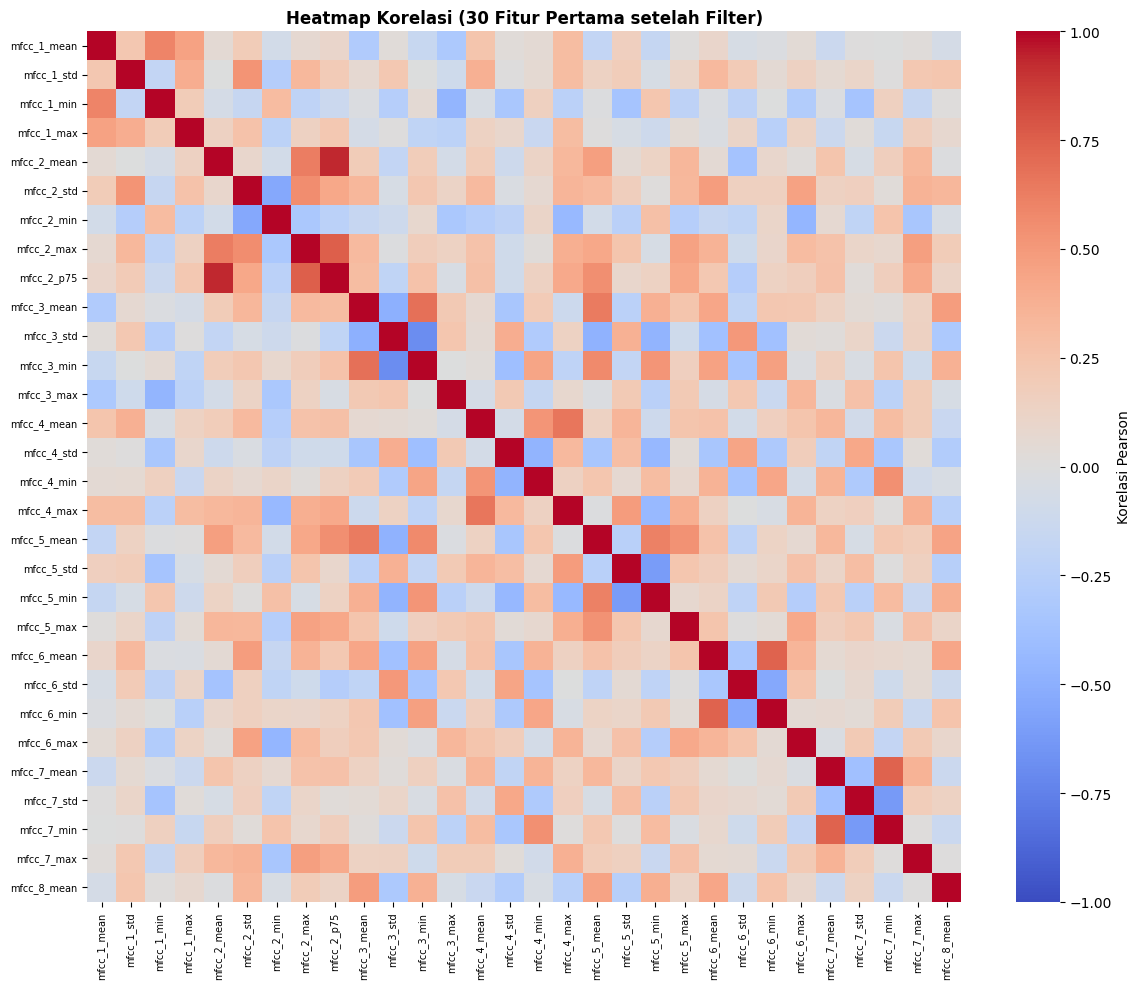

Heatmap korelasi tersimpan.


In [6]:
CORR_THRESHOLD = 0.95

print(f"Menghitung correlation matrix ({len(FEAT_COLS)} × {len(FEAT_COLS)})...")
corr_matrix = df[FEAT_COLS].corr().abs()

# Ambil upper triangle
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identifikasi kolom yang berkorelasi tinggi
to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > CORR_THRESHOLD)]

print(f"Fitur yang dihapus (korelasi > {CORR_THRESHOLD}): {len(to_drop)}")
if to_drop:
    print(f"  Contoh 5 pertama: {to_drop[:5]}")

FEAT_COLS_FILTERED = [f for f in FEAT_COLS if f not in to_drop]
print(f"Fitur tersisa setelah filter korelasi: {len(FEAT_COLS_FILTERED)}")

# Visualisasi heatmap korelasi (subset 30 fitur pertama)
fig, ax = plt.subplots(figsize=(12, 10))
sample_feats = FEAT_COLS_FILTERED[:30]
sns.heatmap(
    df[sample_feats].corr(),
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    ax=ax, cbar_kws={'label': 'Korelasi Pearson'},
    xticklabels=True, yticklabels=True
)
ax.set_title(f'Heatmap Korelasi (30 Fitur Pertama setelah Filter)', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'p4_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap korelasi tersimpan.")


## 4.5 — Seleksi Fitur: ANOVA F-test + Mutual Information
Mengidentifikasi fitur yang paling diskriminatif antara kelas Depresi vs Non-Depresi.


In [7]:
X = df[FEAT_COLS_FILTERED].values
y = df['label_3kelas'].values  # Multiclass: 0=Stress, 1=Kecemasan, 2=Depresi

# ANOVA F-test
f_scores, p_values = f_classif(X, y)

# Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)

# Gabungkan ke DataFrame untuk analisis
df_selection = pd.DataFrame({
    'feature'   : FEAT_COLS_FILTERED,
    'f_score'   : f_scores,
    'p_value'   : p_values,
    'mi_score'  : mi_scores,
    'significant': p_values < 0.05
})
df_selection = df_selection.sort_values('mi_score', ascending=False)

n_sig = df_selection['significant'].sum()
print(f"Fitur signifikan (p < 0.05) untuk 3 kelas: {n_sig} / {len(FEAT_COLS_FILTERED)}")
print(f"\nTop 15 fitur (berdasarkan Mutual Information):")
print(df_selection.head(15)[['feature', 'f_score', 'mi_score', 'significant']].to_string(index=False))


Fitur signifikan (p < 0.05) untuk 3 kelas: 5 / 86

Top 15 fitur (berdasarkan Mutual Information):
                feature  f_score  mi_score  significant
 spectral_bandwidth_p75 1.782602  0.121114        False
             mfcc_9_min 2.079422  0.081736        False
 spectral_centroid_mean 0.974557  0.065361        False
             pitch_mean 1.364065  0.064798        False
             mfcc_5_max 0.565403  0.058999        False
            mfcc_9_mean 0.977173  0.052618        False
             mfcc_3_min 0.019695  0.049860        False
            mfcc_3_mean 1.665976  0.047352        False
             mfcc_2_std 0.865164  0.046987        False
             mfcc_5_min 1.491941  0.046317        False
             mfcc_2_min 1.534359  0.045765        False
              pitch_p75 2.341751  0.045291        False
         rms_energy_std 1.457524  0.043499        False
spectral_bandwidth_mean 1.305818  0.042935        False
            mfcc_8_mean 3.725661  0.038795         True


## 4.6 — Visualisasi: Top 20 Fitur berdasarkan MI Score


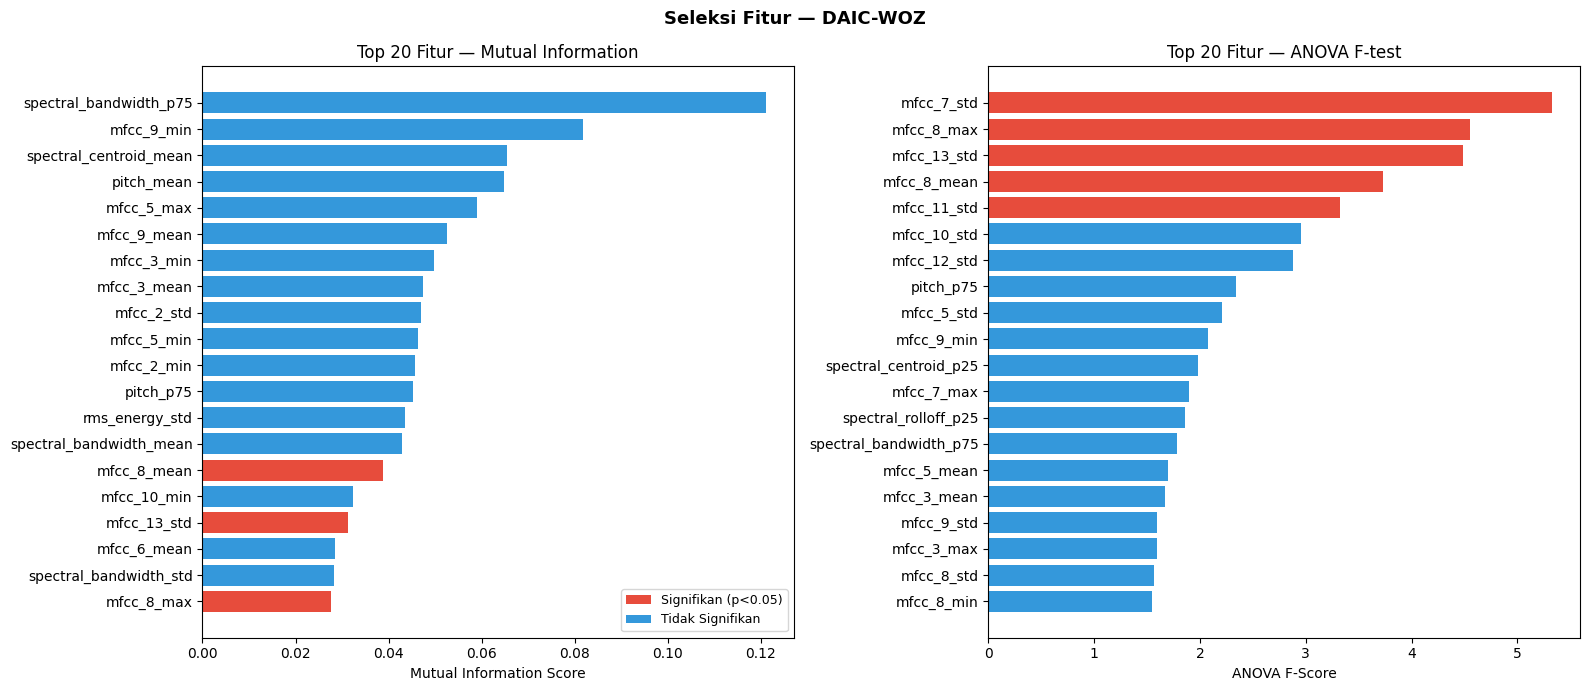

Visualisasi seleksi fitur tersimpan.


In [8]:
top20 = df_selection.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Seleksi Fitur — DAIC-WOZ', fontsize=13, fontweight='bold')

# Mutual Information
colors_mi = ['#e74c3c' if sig else '#3498db' for sig in top20['significant']]
axes[0].barh(top20['feature'][::-1], top20['mi_score'][::-1], color=colors_mi[::-1])
axes[0].set_xlabel('Mutual Information Score')
axes[0].set_title('Top 20 Fitur — Mutual Information')
axes[0].axvline(x=0, color='black', linewidth=0.5)
# Tambahkan legend manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Signifikan (p<0.05)'),
                   Patch(facecolor='#3498db', label='Tidak Signifikan')]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=9)

# F-Score
top20_f = df_selection.nlargest(20, 'f_score')
colors_f = ['#e74c3c' if sig else '#3498db' for sig in top20_f['significant']]
axes[1].barh(top20_f['feature'][::-1], top20_f['f_score'][::-1], color=colors_f[::-1])
axes[1].set_xlabel('ANOVA F-Score')
axes[1].set_title('Top 20 Fitur — ANOVA F-test')

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'p4_feature_selection.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi seleksi fitur tersimpan.")


## 4.7 — Tentukan Fitur Final
Menggunakan fitur yang signifikan secara statistik (p < 0.05) ATAU masuk top-N MI.
Strategi konservatif: ambil semua fitur yang lolos setidaknya satu kriteria.


In [9]:
TOP_N_MI = 50  # Ambil top-N berdasarkan MI jika jumlah signifikan terlalu sedikit

sig_feats = df_selection[df_selection['significant']]['feature'].tolist()
top_mi_feats = df_selection.head(TOP_N_MI)['feature'].tolist()

# Gabung (union) kedua kriteria
final_feats = list(set(sig_feats) | set(top_mi_feats))
final_feats = [f for f in FEAT_COLS_FILTERED if f in final_feats]  # Jaga urutan asli

print(f"Fitur signifikan (p<0.05) : {len(sig_feats)}")
print(f"Top {TOP_N_MI} MI           : {len(top_mi_feats)}")
print(f"Fitur final (union)        : {len(final_feats)}")


Fitur signifikan (p<0.05) : 5
Top 50 MI           : 50
Fitur final (union)        : 51


## 4.8 — Simpan Dataset Final


In [10]:
df_final = df[META_COLS + final_feats].copy()
df_final.to_csv(OUTPUT_FINAL, index=False)

print(f"Dataset final tersimpan: {OUTPUT_FINAL}")
print(f"Shape: {df_final.shape}")
print(f"\nRingkasan:")
print(f"  Partisipan    : {df_final.shape[0]}")
print(f"  Fitur final   : {len(final_feats)}")
for k, name in {0:'Stress', 1:'Kecemasan', 2:'Depresi'}.items():
    n = int((df_final['label_3kelas'] == k).sum())
    print(f"  {name:12s}  : {n}")

# Simpan juga daftar fitur final untuk referensi di Part 5-7
feat_list_path = os.path.join(PROCESSED_DIR, 'daic_feature_list.txt')
with open(feat_list_path, 'w') as f:
    f.write('\n'.join(final_feats))
print(f"\nDaftar fitur tersimpan: {feat_list_path}")
print(f"Sample 10 fitur final:")
for feat in final_feats[:10]:
    print(f"  {feat}")

Dataset final tersimpan: d:\repositories\menthealth-ml\dataset\processed\daic_features_final.csv
Shape: (188, 55)

Ringkasan:
  Partisipan    : 188
  Fitur final   : 51
  Stress        : 82
  Kecemasan     : 90
  Depresi       : 16

Daftar fitur tersimpan: d:\repositories\menthealth-ml\dataset\processed\daic_feature_list.txt
Sample 10 fitur final:
  mfcc_2_mean
  mfcc_2_std
  mfcc_2_min
  mfcc_2_p75
  mfcc_3_mean
  mfcc_3_min
  mfcc_3_max
  mfcc_4_std
  mfcc_4_min
  mfcc_4_max
